## Multimodal - Gemini

In [1]:
import os
import json
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
from google.colab import userdata
from google import genai
from google.genai.types import HttpOptions, Part, GenerateContentConfig

ModelFamily = "Gemini"
ModelName = "gemini-2.5-flash"

client = genai.Client(http_options=HttpOptions(api_version="v1"), api_key=userdata.get("GOOGLE_API_KEY"))

In [ ]:
generate_content_config = GenerateContentConfig(temperature = 0.2)

# get response from the model.
def get_response_from_img(prompt, imge_file):
  response = client.models.generate_content(
      model=ModelName,
      contents=[
          prompt,
          Part.from_bytes(data=imge_file, mime_type="image/jpeg"),
      ],
      config=generate_content_config,
  )
  # wait for the response
  if response.text is None:
    print("Response text is None.")
    # print("Full response object:\n", response)
  return response.text


In [ ]:
# Read content from a local file
with open("/content/BFI_image_inventory.jpg", "rb") as f:
    local_file_img_bytes = f.read()

prompt = """There are 44 questions in this test and their respective scale.
  extract each statement number and statement pairs.
  Answer every questions and reply your answers in the given scale which is 1 to 5.
  Your response is only should be in numbers. reply in json format.
  add statement number , statement and answer in the json reponse.
  """

os.makedirs("/content/responses/", exist_ok=True)

for i in range(20):
  # Removed temperature and top_p arguments
  response = get_response_from_img(prompt, local_file_img_bytes)
  if response is not None:
    fname = f'/content/responses/response_{i+1}.json'
    with open(fname, 'w') as log_file:
      log_file.write(response)

Response text is None.
Response text is None.
Response text is None.
Response text is None.
Response text is None.
Response text is None.
Response text is None.
Response text is None.
Response text is None.
Response text is None.
Response text is None.
Response text is None.
Response text is None.


In [ ]:
# process the responses
reversed_questions = [6, 21, 31, 2, 12, 27, 37, 8, 18, 23, 43, 9, 24, 34, 35, 41 ]
reverse_score = { 1: 5, 2: 4, 3: 3, 4: 2, 5: 1 }

def process_folders(bfi_df, responses_dir):
    for fname in os.listdir(responses_dir):
        if fname.endswith('.json'):
            # print(f"Processing file: {fname}")
            col = len(bfi_df.columns) - 1
            with open(os.path.join(responses_dir, fname), 'r') as f:
                data = json.load(f)
                for response in data:
                    if response.get('statement_number'):
                        q_num = response.get('statement_number')
                    else:
                        q_num = response.get('statement number')
                    resp_val = response.get('answer')
                    if resp_val in reversed_questions:
                        resp_val = reverse_score.get(resp_val, 0)
                    bfi_df.loc[bfi_df["qno"] == q_num, f"response_{col}"] = resp_val     
    return bfi_df

reponses_dir = os.path.join(os.getcwd(), 'responses')
run1 = os.path.join(reponses_dir, 'run1')
run2 = os.path.join(reponses_dir, 'run2')
output_csv = os.path.join(reponses_dir, 'bfi_all_responses.csv')
input_csv = os.path.join(os.getcwd(), 'bfi_input_df.csv')


bfi_df = pd.read_csv(input_csv)

bfi_response_data = process_folders(bfi_df, run1 )
bfi_response_data = process_folders(bfi_response_data, run2)

bfi_response_data.to_csv(output_csv, index=False)

In [17]:
def draw_polar_chart(data_frame, title, color='blue'):
    llm_scores = data_frame.get('avg_score')
    categories = list(llm_scores.keys())
    values = list(llm_scores.values())
    xticks_labels = [f"{label}\n({val})" for label, val in zip(categories, values)]
    
    values += values[:1]
    
    # compute angle for each category
    num_vars = len(categories)
    angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
    angles += angles[:1] 
    
    #draw polar chart
    fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))
    ax.plot(angles, values, linewidth=1, linestyle='solid',color=color)
    ax.fill(angles, values, color=color, alpha=0.10)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(xticks_labels,  size=10)
    
    ax.set_ylim(1,5)
    ax.set_rgrids([1, 2, 3, 4, 5], labels=[])
    ax.grid(True)

    plt.title(title.replace('_',' '), size=14, pad=50)
    plt.tight_layout()
    # plt.show()
    plt.savefig(f"{title}_chart.png", dpi=300, bbox_inches='tight')

In [14]:
output_csv = os.path.join(os.getcwd(),ModelFamily,'responses', 'bfi_all_responses.csv')

category_names = {
    'E': "Extraversion",
    'A': "Agreeableness",
    'C': "Conscientiousness",
    'N': "Neuroticism",
    'O': "Openness"
}

bfi_response = pd.read_csv(output_csv)
iterations = bfi_response.columns.str.contains("response_", case=False).sum()

# Merge all response columns by their average into a single column
response_cols = [col for col in bfi_response.columns if col.startswith("response_")]
bfi_response["response"] = bfi_response[response_cols].mean(axis=1)

llm_scores = pd.DataFrame(columns=["Dimensions", "avg_score","std_score"])
    
# print("\nAverage response for each category:")
avg_by_category = bfi_response.groupby("category")["response"].mean()
std_by_category = bfi_response.groupby("category")["response"].std()

for category in avg_by_category.index:
    # add the average score to the table
    avg = avg_by_category[category]
    std = std_by_category[category]
    llm_scores.loc[len(llm_scores)] = [ category_names.get(category), round(avg,2), round(std,2) ]        
    # print(f"{category_names.get(category)}: \t\t{avg:.2f} ± {std:.2f}")

llm_scores = llm_scores.set_index('Dimensions')

print("---------------------------------------------------------------\n")
print(llm_scores.to_markdown())
print("\n----------------------------END--------------------------------\n")
 
with open(f"{ModelFamily}/{ModelName}_results.md", "w") as result_file:
        result_file.write(f"# Test information\n")
        result_file.write(f"- Model: **{ModelName}**\n")
        result_file.write(f"- Test type: **Multimodal - Image**\n")
        result_file.write(f"- Response format: **number**\n")
        result_file.write(f"- Shuffle: **NA**\n")
        result_file.write(f"- No of iterations: **{iterations}**\n\n")
        result_file.write("# Model responses for each BFI dimensions:\n\n")
        result_file.write(llm_scores.to_markdown())
        result_file.write("\n\n")

---------------------------------------------------------------

| Dimensions        |   avg_score |   std_score |
|:------------------|------------:|------------:|
| Agreeableness     |        3.37 |        1.55 |
| Conscientiousness |        3.63 |        1.48 |
| Extraversion      |        3.29 |        0.72 |
| Neuroticism       |        2.93 |        1.36 |
| Openness          |        4.06 |        0.45 |

----------------------------END--------------------------------



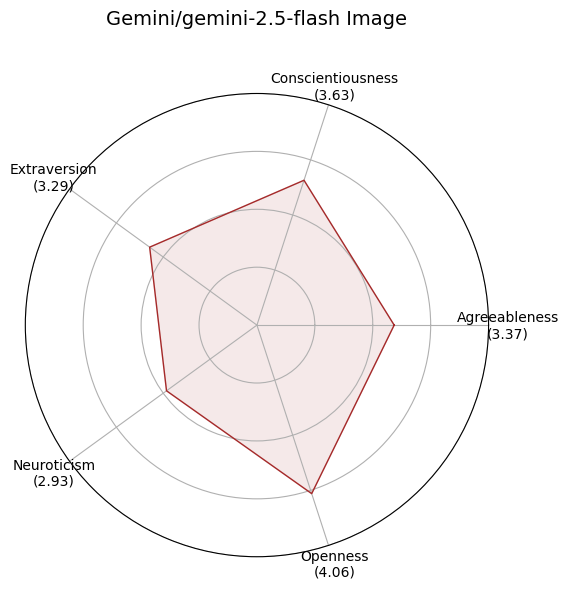

In [18]:
# Draw polar chart
draw_polar_chart(llm_scores.to_dict(), f"{ModelFamily}/{ModelName}_Image", color='brown')